In [1]:
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
y = np.array([28, 8, -3, 7, -1, 1, 18, 12])
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18])

In [7]:
from scipy.stats import gaussian_kde

In [18]:
np.random.seed(0)
n_samples = 10_000
data = {}
for i, (mu, sd) in enumerate(zip(y, sigma), start=1):
    data[f"School {i}"] = np.random.normal(mu, sd, n_samples)

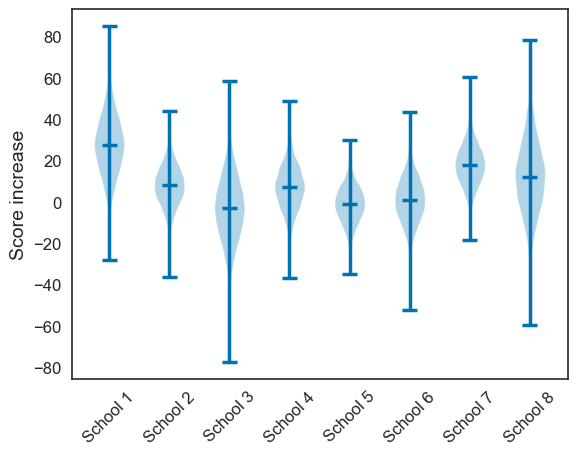

In [19]:
plt.violinplot([data[k] for k in data], showmeans=True)
plt.xticks(
    [i + 1 for i in range(8)],
    [k for k in data],
    rotation=45,
)
plt.ylabel("Score increase")
plt.show()

In [2]:
from scipy.stats import norm, halfnorm

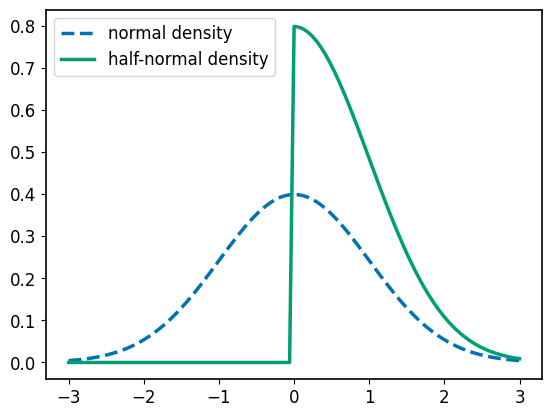

In [7]:
xs = np.linspace(-3, 3, 101)

plt.plot(
    xs,
    norm.pdf(xs, 0, 1),
    linestyle="--",
    label="normal density"
)

plt.plot(
    xs, halfnorm.pdf(xs, 0, 1),
    label="half-normal density",
)

plt.legend()
plt.show()

In [7]:
from scipy.stats import gamma, norm
from sklearn.mixture import GaussianMixture

In [4]:
# --- Target distribution: skewed Gamma ---
x = np.linspace(0, 20, 500)
target_pdf = gamma(a=5, scale=1).pdf(x)

# --- Helper: Gaussian mixture PDF ---
def gaussian_mixture_pdf(x, weights, mus, sigmas):
    pdf = np.zeros_like(x)
    for w, mu, sigma in zip(weights, mus, sigmas):
        pdf += w * norm.pdf(x, mu, sigma)
    return pdf

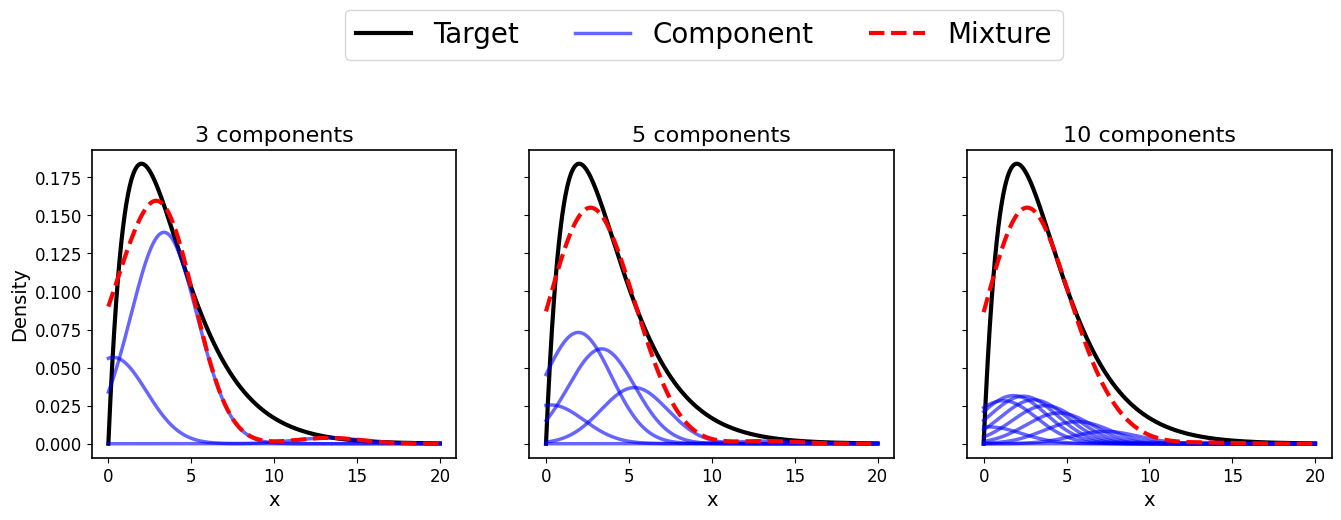

In [42]:
shape, scale = 2., 2.
x = np.linspace(0, 20, 1000)
true_pdf = gamma(a=shape, scale=scale).pdf(x)

# --- Construct manual Gaussian mixtures with component breakdown ---
def manual_mixture_components(x, n_components):
    quantiles = np.linspace(0.01, 0.99, n_components)
    means = gamma(a=shape, scale=scale).ppf(quantiles)
    weights = gamma(a=shape, scale=scale).pdf(means)
    weights /= weights.sum()
    std = scale
    components = [w * norm.pdf(x, loc=m, scale=std) for m, w in zip(means, weights)]
    mixture_pdf = np.sum(components, axis=0)
    return mixture_pdf, components, means, weights

# --- Different component counts ---
component_list = [3, 5, 10]
results = {k: manual_mixture_components(x, k) for k in component_list}

# --- Plot ---
fig, axes = plt.subplots(1, len(component_list), figsize=(16, 4), sharey=True)

for ax, k in zip(axes, component_list):
    mixture_pdf, components, means, weights = results[k]
    ax.plot(x, true_pdf, 'k-', lw=3, label="Target")
    # plot individual components
    for i, comp in enumerate(components):
        ax.plot(x, comp, 'b-', alpha=0.6, label="Component" if i == 0 else None)
    ax.plot(x, mixture_pdf, 'r--', lw=3, label=f"Mixture")
    ax.set_title(f"{k} components")
    ax.set_xlabel("x")
    if ax is axes[0]:
        ax.set_ylabel("Density")
    # ax.legend()

plt.legend(
    ncols=3,
    bbox_to_anchor=(0.3, 1.5),
    fontsize=20,
)

# plt.suptitle("Gaussian Mixtures with Individual Components", fontsize=14)
# plt.tight_layout()
plt.show()

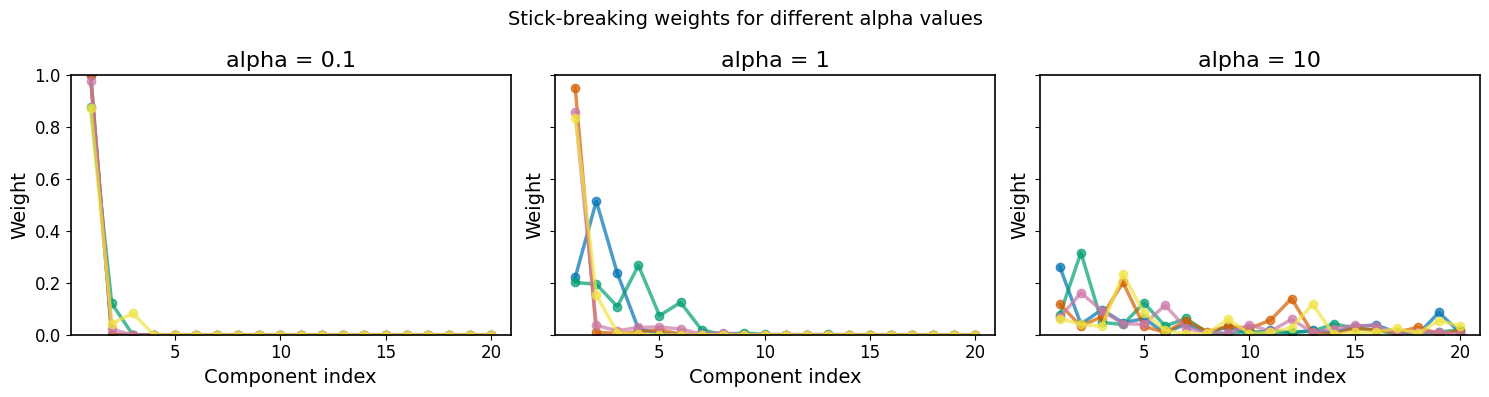

In [20]:
def stick_breaking(alpha, n_components=20, n_samples=5, random_state=None):
    """
    Generate stick-breaking weights for a Dirichlet Process.
    
    Parameters
    ----------
    alpha : float
        Concentration parameter of the DP.
    n_components : int
        Number of components to approximate (truncation level).
    n_samples : int
        Number of different stick-breaking draws to visualize.
    random_state : int, optional
        Random seed for reproducibility.
    """
    rng = np.random.default_rng(random_state)
    weights_all = []
    for _ in range(n_samples):
        betas = rng.beta(1, alpha, size=n_components)
        remaining_stick = np.concatenate(([1.0], np.cumprod(1 - betas[:-1])))
        weights = betas * remaining_stick
        weights_all.append(weights)
    return np.array(weights_all)

# Parameters for visualization
alphas = [0.1, 1, 10]
n_components = 20
n_samples = 5

fig, axes = plt.subplots(1, len(alphas), figsize=(15, 4), sharey=True)

for ax, alpha in zip(axes, alphas):
    weights_samples = stick_breaking(alpha, n_components, n_samples, random_state=42)
    for weights in weights_samples:
        ax.plot(range(1, n_components + 1), weights, marker="o", alpha=0.7)
    ax.set_title(f"alpha = {alpha}")
    ax.set_xlabel("Component index")
    ax.set_ylabel("Weight")
    ax.set_ylim(0, 1)

fig.suptitle("Stick-breaking weights for different alpha values", fontsize=14)
plt.tight_layout()
plt.show()